In [9]:
# ============================
# 1. Importera bibliotek
# ============================

import shap
import joblib
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt


In [10]:
# ============================
# 2. Ladda bästa modellen + data
# ============================

import joblib

# Ladda modellen (från modeling-notebooken)
model = joblib.load("../models/best_model.pkl")

# Ladda data
X_train = joblib.load("../data/X_train.pkl")
X_test = joblib.load("../data/X_test.pkl")
y_train = joblib.load("../data/y_train.pkl")
y_test = joblib.load("../data/y_test.pkl")


In [11]:
# ============================
# 3. Skapa SHAP-explainer
# ============================

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)


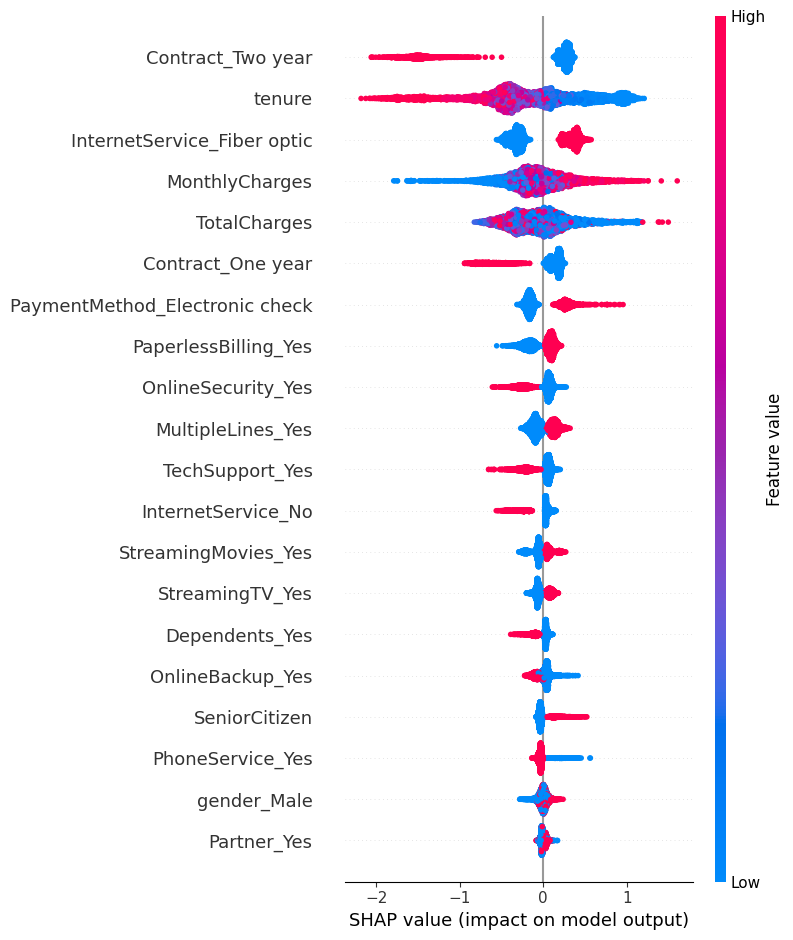

In [12]:
# ============================
# 4. SHAP Summary Plot
# ============================

shap.summary_plot(shap_values, X_train)


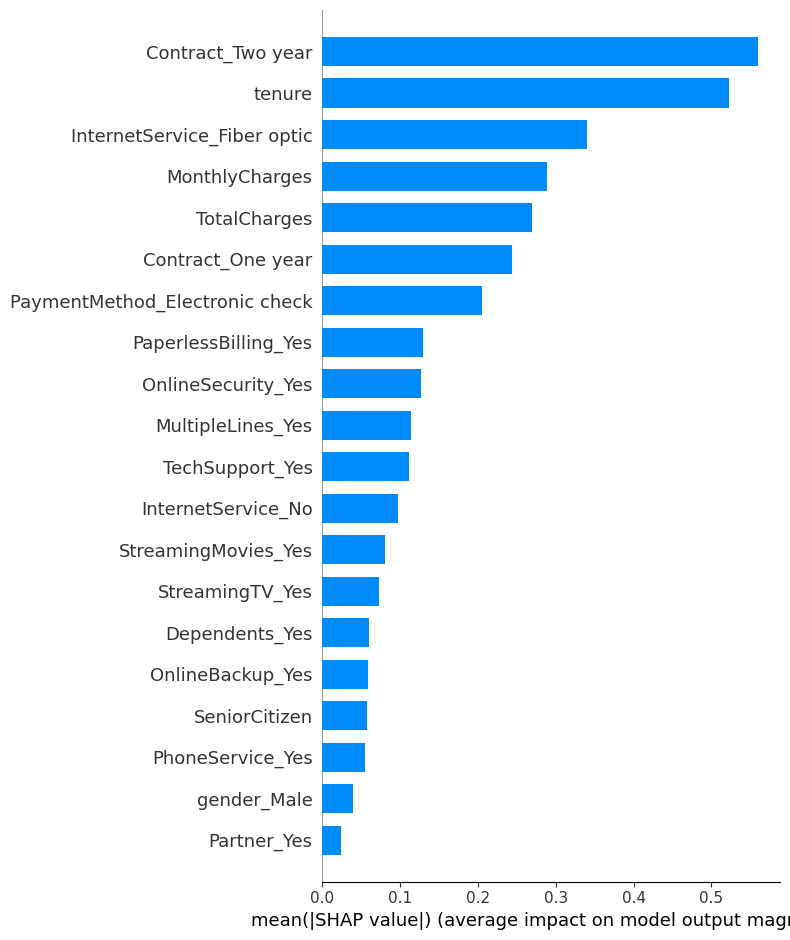

In [13]:
# ============================
# 5. SHAP Bar Plot (Feature Importance)
# ============================

shap.summary_plot(shap_values, X_train, plot_type="bar")


In [14]:
# ============================
# 6. SHAP Force Plot för en enskild kund
# ============================

# Välj en rad (t.ex. första kunden i testdatan)
index = 0

shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[index],
    X_train.iloc[index]
)


In [15]:
# ============================
# 7. SHAP values som DataFrame
# ============================

shap_df = pd.DataFrame(shap_values, columns=X_train.columns)
shap_df.head()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-0.044947,-0.596094,0.060880,-0.535452,0.057805,-0.026424,0.049395,0.332916,0.029338,-0.045783,...,0.0,0.090304,0.0,0.050533,0.153148,0.247573,-0.223244,0.014018,0.305466,0.023908
1,-0.073596,0.172167,-0.229845,0.226308,-0.010475,0.048421,-0.083727,-0.024403,-0.002106,-0.115761,...,0.0,-0.075436,0.0,-0.069867,0.195689,0.284257,-0.254808,0.007088,-0.182374,-0.093788
2,-0.049994,0.045137,-0.084864,-0.248585,0.023978,0.039618,-0.171972,0.112527,0.013332,-0.077683,...,0.0,-0.080833,0.0,-0.026842,0.080050,-1.709299,-0.091408,-0.008111,-0.219858,-0.083126
3,-0.043761,-0.396714,-0.212789,-0.418155,0.012653,0.024621,0.042205,-0.051492,-0.004495,-0.100842,...,0.0,0.023489,0.0,0.028845,0.059232,-1.828099,0.076114,-0.042616,-0.155977,0.001146
4,-0.043015,0.836594,-0.199802,0.039996,-0.002597,0.100813,-0.076737,-0.064036,-0.006585,-0.015384,...,0.0,-0.067232,0.0,-0.054578,0.177839,0.289538,-0.286790,0.007254,0.195774,0.002515


In [16]:
# ============================
# 8. Spara SHAP-värden
# ============================

joblib.dump(shap_values, "../models/shap_values.pkl")


['../models/shap_values.pkl']